# ⚙️ Notebook 03: Data Transformation & Star Schema Assembly
**โครงการ**: Used Car Analytics (ETL Pipeline & Data Warehouse)

สมุดบันทึกนี้สาธิตกระบวนการ **Data Transformation & Star Schema Assembly**:
1. **Consolidate & Calculate Measures:** รวมตลาดไทย (Kaidee + One2car) และคำนวณ `discount_amount`, `depreciation_amount`, `discount_to_deprec_ratio`, `profit_margin`, `days_on_lot`
2. **Assemble Star Schema:** สร้าง 2 Fact Tables (`FactSales`, `FactMarketListings`) + 5 Dimension Tables (`DimCar`, `DimDate`, `DimLocation` 6 ภาค, `DimCustomer`, `DimAcquisitionSource`)

---

### 1. Setup Environment & Run Cleaned Data

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup path
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(base_dir, "01_Raw_Data")):
    base_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if not os.path.exists(os.path.join(base_dir, "01_Raw_Data")):
    base_dir = os.path.abspath(".")

sys.path.append(os.path.join(base_dir, "02_ETL"))
from src.extract import extract_raw_data
from src.clean import clean_kaidee_data, clean_one2car_data, clean_us_sales_data
from src.transform import transform_data
from src.integrate import integrate_star_schema

# Pipeline execution
df_kaidee_raw, df_one2car_raw, df_us_raw = extract_raw_data(base_dir)
df_kaidee_clean = clean_kaidee_data(df_kaidee_raw)
df_one2car_clean = clean_one2car_data(df_one2car_raw)
df_us_clean = clean_us_sales_data(df_us_raw)

# Transform & Integrate
df_trans, df_us_trans = transform_data(df_kaidee_clean, df_one2car_clean, df_us_clean)
dw_tables = integrate_star_schema(df_trans, df_us_trans)

print("✅ Transformation and Star Schema Assembly Completed!")

[Extract] Ingesting Data Source 1: Kaidee Auto JSON from /home/naeiger/data-min/project-group/01_Raw_Data/kaidee/kaidee_cars_detail.json...
[Extract] Ingesting & Standardizing Data Source 2: 3 raw One2Car scraped period files...
[Extract] Ingesting Data Source 3: US Sales raw data from /home/naeiger/data-min/project-group/01_Raw_Data/us-usecar/used_car_sales.csv...


[Extract Completed] Kaidee Auto JSON: 1,443 rows | One2car Multi-file: 4,190 rows | US Sales: 122,144 rows
[Clean] Cleaning Kaidee Auto JSON dataset...


[Clean Completed] Kaidee Auto cleaned: 1,395 valid rows (Dropped 48 duplicate/invalid rows)
[Clean] Cleaning One2car dataset & extracting BodyType/FuelType features...


[Clean Completed] One2car cleaned: 3,870 valid rows (Dropped 320 duplicate/invalid/trap rows)
[Clean] Cleaning US Sales dataset & filtering typos...
[Clean Completed] US Sales cleaned: 116,659 valid rows (Dropped 5485 typo/duplicate rows)
[Transform] Consolidating Thai Market Listings (Kaidee JSON + One2car Multi-file) & Calculating Measures...
[Transform Completed] Consolidated Thai Market transformed with 5,265 rows with full Measures.
[Integrate] Assembling Star Schema Data Warehouse tables with 6 Official Thailand Regions mapping...
[Integrate Completed] Star Schema assembled: 2 Fact Tables (FactSales: 7166, FactMarketListings: 7166) + 5 Dimensions.
✅ Transformation and Star Schema Assembly Completed!


### 2. Star Schema Table Structure & Row Counts

In [2]:
schema_info = []
for name, df in dw_tables.items():
    table_type = "Fact Table" if name.startswith("Fact") else "Dimension Table"
    schema_info.append({
        "Table Name": name,
        "Table Type": table_type,
        "Row Count": len(df),
        "Column Count": len(df.columns),
        "Columns": ", ".join(df.columns[:5]) + "..."
    })

df_schema_summary = pd.DataFrame(schema_info)
print("=== Star Schema Tables Summary ===")
print(df_schema_summary.to_string(index=False))

=== Star Schema Tables Summary ===
          Table Name      Table Type  Row Count  Column Count                                                              Columns
              DimCar Dimension Table       2366             8                brand, model, model_year, transmission, price_tier...
             DimDate Dimension Table       1096             8                         full_date, date_key, year, quarter, month...
         DimLocation Dimension Table         45             3                                    province, location_key, region...
         DimCustomer Dimension Table        100             4          customer_key, province, payment_method, customer_segment...
DimAcquisitionSource Dimension Table          3             3                            source_key, source_type, supplier_name...
           FactSales      Fact Table       7166            20 sales_id, car_key, date_key, customer_key, acquisition_source_key...
  FactMarketListings      Fact Table       7166 

### 3. Financial Measures Distribution Analysis

/tmp/ipykernel_34990/2852337491.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naeiger/data-min/project-group/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


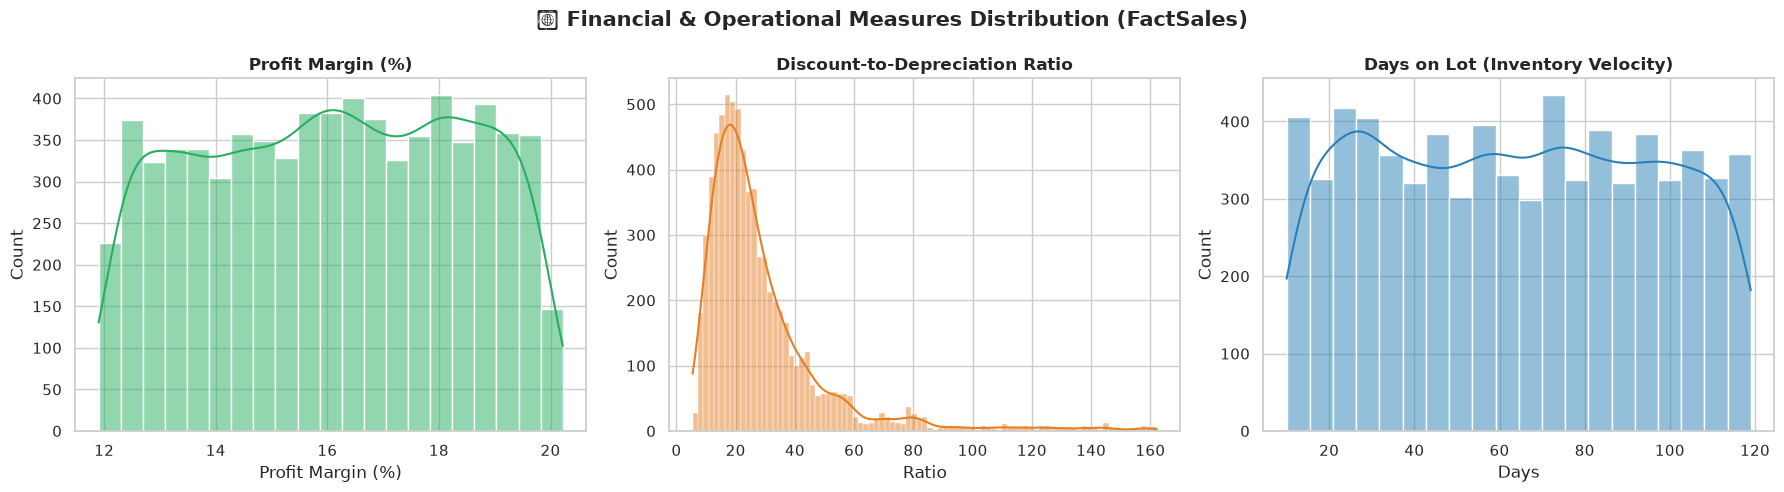

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📈 Financial & Operational Measures Distribution (FactSales)", fontsize=15, fontweight="bold")

fact_sales = dw_tables["FactSales"]

# 1. Profit Margin
sns.histplot(fact_sales["profit_margin"], kde=True, ax=axes[0], color="#27ae60")
axes[0].set_title("Profit Margin (%)", fontweight="bold")
axes[0].set_xlabel("Profit Margin (%)")

# 2. Discount-to-Depreciation Ratio
sns.histplot(fact_sales["discount_to_deprec_ratio"], kde=True, ax=axes[1], color="#e67e22")
axes[1].set_title("Discount-to-Depreciation Ratio", fontweight="bold")
axes[1].set_xlabel("Ratio")

# 3. Days on Lot
sns.histplot(fact_sales["days_on_lot"], kde=True, ax=axes[2], color="#2980b9")
axes[2].set_title("Days on Lot (Inventory Velocity)", fontweight="bold")
axes[2].set_xlabel("Days")

plt.tight_layout()
plt.show()